예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 3-3 좀 더 복잡한 분류 문제

본 노트북은 본문 3-3절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 데이터 확인 및 준비과정
- 다중 클래스 분류를 위한 원-핫 인코딩
- 모델의 정의와 `nn.Sequential`의 다양한 활용법
- 모델 학습과 평가
- 교차 엔트로피 손실 함수 도입
- ReLU 활성화 함수 도입

본문의 모델 4의 구현에 해당되며, 모델 4의 제시문은 다음과 같다.

> **모델 4. 회오리 모양으로 분포한 데이터 분류 모델**
>
> 깃허브 저장소의 `data/ch3_spiral_data.csv` 파일의 첫 여섯 행은 다음과 같다.
>
> ```
> x1,x2,label
> 0.21783796,-0.085766256,0
> -0.17071004,-0.7397558,2
> -0.26482427,0.725769,0
> -0.3277686,-0.9057277,1
> 0.1151537,0.061260574,0
> ```
>
> 900개의 데이터 샘플이 포함된 이 파일의 각 줄은 두 개의 입력(`x1`, `x2`)과 하나의 정답(`label`)을 쉼표로 구분해 나타낸다. 단, 첫 줄은 데이터 샘플이 아니라 열의 이름이다. 데이터의 정답은 `0`, `1`, `2`의 셋 중 하나이며, 이 값은 수치가 아니라 각 데이터가 속한 클래스의 번호를 나타낸다. 이 데이터를 클래스를 구분해 `x1`과 `x2`의 좌표 평면에 표시하면 다음과 같다.
>
> (그림은 아래 [그림 3-10] 회오리 모양 데이터 분포 시각화 셀 참조)
>
> 이와 같이 분포한 데이터를 0, 1, 2 세 클래스로 분류하는 다층 퍼셉트론 모델을 만들어 보자.



## 데이터 준비 과정

- CSV 형식 파일의 데이터를 리스트로 불러온 후(표준 라이브러리의 `csv` 모듈 사용)
- 리스트를 텐서로 변환

In [3]:
########################################################################################
# 코드 3-7 - CSV 형식 파일의 데이터로 텐서 생성
########################################################################################
import csv
import torch

# CSV 파일 저장 경로
data_path = '../../data/ch3_spiral_data.csv'

X_list, Y_list = [], []
with open(data_path, 'r') as f:
    # csv.DictReader 객체로 루프를 만들어 사용 (열 이름이 명시된 머리줄이 있는 경우)
    reader = csv.DictReader(f)              # 머리줄을 열 이름으로 자동 처리
    for row in reader:                      # row: 각 데이터 샘플의 딕셔너리
        X_list.append([float(row['x1']), float(row['x2'])])
        Y_list.append(int(row['label']))

# 리스트를 텐서로 변환
X = torch.tensor(X_list)                    # (900, 2) 형태의 텐서
Y = torch.tensor(Y_list)                    # (900,) 형태의 텐서

- 데이터 샘플을 6:4의 비율로 나눠 훈련용 데이터와 평가용 데이터로 분리해 사용

In [4]:
########################################################################################
# 코드 3-7 - CSV 형식 파일의 데이터로 텐서 생성(계속)
########################################################################################

# 데이터를 6:4 비율로 훈련용 데이터(X_train, Y_train)와 평가용 데이터(X_test, Y_test)로 나눔
train_size = int(len(Y) * 0.6)              # 훈련 데이터 샘플 수
X_train = X[:train_size]                    # 훈련 데이터(입력)
Y_train = Y[:train_size]                    # 훈련 데이터(정답)
X_test = X[train_size:]                     # 평가 데이터(입력)
Y_test = Y[train_size:]                     # 평가 데이터(정답)


print(f'전체 샘플 수: {len(X)}')
print(f'훈련 샘플 수: {len(X_train)}, 평가 샘플 수: {len(X_test)}')

전체 샘플 수: 900
훈련 샘플 수: 540, 평가 샘플 수: 360


- 참고: 회오리 데이터 분포 시각화([그림 3-10])
    - 데이터 분포를 확인해야 이에 맞는 모델을 만들 수 있으며,
    - 시각화가 가능하다면 눈으로 확인하는 과정을 반드시 거쳐야 함
    - 세 개의 클래스를 각각 색깔과 모양 기호로 구분해 시각화

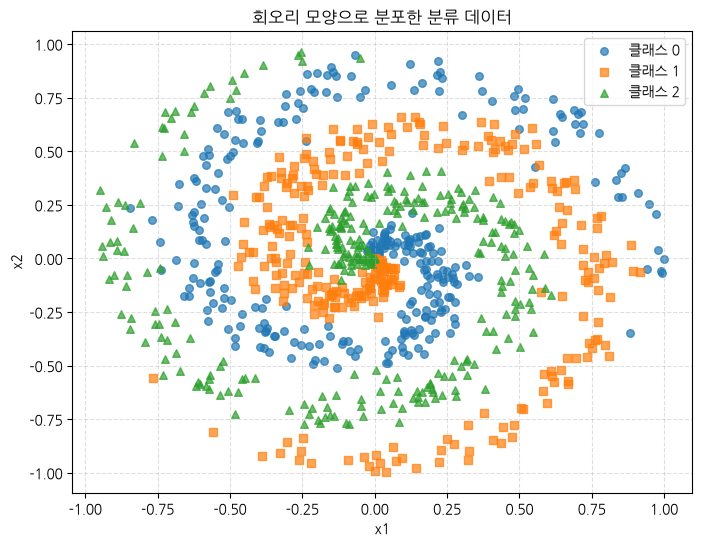

In [5]:
# 참고 - 데이터 분포 시각화 ([그림 3-10])

viz.plot_scatter(
    X, Y,
    class_names=['클래스 0', '클래스 1', '클래스 2'],
    title='회오리 모양으로 분포한 분류 데이터',
    x_label='x1', y_label='x2',
)

- 다중 클래스 분류를 위한 원-핫 인코딩
    - 다중 클래스 분류에서 클래스별 고유 번호(정답)를 부여한 후(0부터 차례로 부여),
    - 정답의 크기에 따른 편견이 발생하지 않도록 원-핫 인코딩해 사용
- `torch.nn.functional.one_hot()`: 파이토치의 원-핫 인코딩 함수
    - 주어진 고유 번호를 원-핫 벡터로 인코딩
    - `num_classes` 인자: 전체 클래스수로 원-핫 벡터의 크기와 같음
    - 고유번호는 `0` 이상 `num_classes` 미만의 정수여야 함
    - 관례상 `torch.nn.functional` 패키지는 `F` 별칭으로 사용(`import torch.nn.functional as F`)

In [6]:
########################################################################################
# 코드 3-8 - 파이토치의 원-핫 인코딩 함수 one_hot()
########################################################################################

# torch.nn.functional 패키지는 보통 F라는 별칭으로 import함
import torch.nn.functional as F

class_1 = torch.tensor([1])
class_all = torch.tensor([0, 1, 2])
print(f'클래스가 3개일 때 두 번째 클래스의 원-핫 벡터: ',
      F.one_hot(class_1, num_classes=3))
print(f'클래스가 4개일 때 두 번째 클래스의 원-핫 벡터: ',
      F.one_hot(class_1, num_classes=4))

# 여러 클래스의 원-핫 벡터를 한 번에 만들면 차원이 하나 더 늘어남: (3,) -> (3, 3)
print(f'클래스가 3개일 때 모든 클래스의 원-핫 벡터:\n',
      F.one_hot(class_all, num_classes=3))

class_all = torch.cat([class_all, torch.tensor([3])])
print(f'클래스가 4개일 때 모든 클래스의 원-핫 벡터:\n',
      F.one_hot(class_all, num_classes=4))


클래스가 3개일 때 두 번째 클래스의 원-핫 벡터:  tensor([[0, 1, 0]])
클래스가 4개일 때 두 번째 클래스의 원-핫 벡터:  tensor([[0, 1, 0, 0]])
클래스가 3개일 때 모든 클래스의 원-핫 벡터:
 tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]])
클래스가 4개일 때 모든 클래스의 원-핫 벡터:
 tensor([[1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]])


- 훈련용과 평가용으로 나눠 둔 정답 텐서를 한꺼번에 원-핫 텐서로 인코딩

In [7]:
########################################################################################
# 코드 3-9 - 정답 데이터를 원-핫 텐서로 변경
########################################################################################

# 훈련용 데이터의 정답 원-핫 텐서
Y_train_onehot = F.one_hot(Y_train, num_classes=3).float()  # (540,) -> (540, 3)
# 평가용 데이터의 정답 원-핫 텐서
Y_test_onehot = F.one_hot(Y_test, num_classes=3).float()    # (360,) -> (360, 3)

print(f'Y_train_onehot 형태: {Y_train_onehot.shape}')
print(f'Y_test_onehot  형태: {Y_test_onehot.shape}')

Y_train_onehot 형태: torch.Size([540, 3])
Y_test_onehot  형태: torch.Size([360, 3])


- 모델의 정의와 `nn.Sequential`의 다양한 활용법
    - `SpiralMLP` 클래스: 뉴런이 64개인 두 개의 은닉층을 가진 다층 퍼셉트론 모델 정의
    - 모델 구조 하이퍼파라미터(`HIDDEN_DIM`)의 값을 지정하고 모델 객체 생성


In [8]:
########################################################################################
# 코드 3-10 - 두 개의 은닉층을 가진 다층 퍼셉트론 모델 정의
########################################################################################

import torch.nn as nn

# 두 개의 은닉층과 하나의 출력층으로 구성된 다층 퍼셉트론 모델 클래스
class SpiralMLP(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_layer1 = nn.Linear(2, hidden_dim)               # 은닉층 1
        self.hidden_layer2 = nn.Linear(hidden_dim, hidden_dim)      # 은닉층 2
        self.output_layer = nn.Linear(hidden_dim, 3)                # 출력층
        self.activation = nn.Sigmoid()                              # 활성화 함수

    # 두 은닉층과 출력층을 거쳐 모델의 출력을 반환하는 forward() 메서드
    def forward(self, x):
        x = self.hidden_layer1(x)      # (N, 2) -> (N, 64) (N은 샘플의 수, hidden_dim=64)
        x = self.activation(x)
        x = self.hidden_layer2(x)      #        -> (N, 64)
        x = self.activation(x)
        x = self.output_layer(x)       #        -> (N, 3)
        x = self.activation(x)
        return x

HIDDEN_DIM = 64                        # 은닉층 뉴런의 수
model = SpiralMLP(HIDDEN_DIM)

# 모델 구성 계층 출력
print(model)

SpiralMLP(
  (hidden_layer1): Linear(in_features=2, out_features=64, bias=True)
  (hidden_layer2): Linear(in_features=64, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=3, bias=True)
  (activation): Sigmoid()
)


- `nn.Sequential` 클래스
    - 여러 계층의 묶음을 정의하는 컨테이너
    - 계층 객체를 데이터 흐름 순서대로 인자로 전달해 간결하게 모델 생성 가능
    - 계층 클래스가 아닌 계층 객체를 인자로 전달해야 한다는 점에 주의


In [9]:
########################################################################################
# 코드 3-11 - nn.Sequential로 모델 정의
########################################################################################
from torchinfo import summary

# 모델 구성 계층 객체를 데이터 흐름 순서대로 인자로 전달해 모델 생성
# 클래스(nn.Linear)가 아닌 객체(nn.Linear())를 인자로 전달, 계층 객체의 수는 제한이 없음
model = nn.Sequential(
    nn.Linear(2, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, 3),
    nn.Sigmoid()
)

# 모델 구조 확인
summary(model, input_size=(540, 2), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [540, 3]                  --
├─Linear: 1-1                            [540, 64]                 192
├─Sigmoid: 1-2                           [540, 64]                 --
├─Linear: 1-3                            [540, 64]                 4,160
├─Sigmoid: 1-4                           [540, 64]                 --
├─Linear: 1-5                            [540, 3]                  195
├─Sigmoid: 1-6                           [540, 3]                  --
Total params: 4,547
Trainable params: 4,547
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.46
Input size (MB): 0.00
Forward/backward pass size (MB): 0.57
Params size (MB): 0.02
Estimated Total Size (MB): 0.59

- `nn.Sequential` 클래스(계속)
    - 미리 만들어둔 계층 리스트를 사용해 모델 생성 가능
        - 다만 리스트를 직접 인자로 전달할 수 없고, 언패킹(`*layers`)해 전달해야 함
    - `len(model)`: `nn.Sequential`로 만든 모델의 계층 수
        - `nn.Module`을 상속받아 만든 경우 `len()` 사용할 수 없음

In [10]:
########################################################################################
# 코드 3-12 - 미리 만들어둔 계층 리스트를 언패킹으로 전달
########################################################################################

# 계층 객체의 리스트
layers = [
    nn.Linear(2, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, 3),
    nn.Sigmoid()
]

# nn.Sequential(layers)와 같이 언패킹 없이 리스트를 인자로 전달하면 예외가 발생함
model = nn.Sequential(*layers)

# len(model): nn.Sequential로 만든 모델의 계층 수
print(f'모델 계층 수: {len(model)}')

모델 계층 수: 6


- `nn.Sequential` 클래스(계속)
    - `pop()`: 계층을 제거하고 반환
    - `insert()`: 계층을 추가
    - 리스트의 `pop()`, `insert()`와 같이 인덱스 기반으로 동작

In [11]:
########################################################################################
# 코드 3-13 - nn.Sequential 객체에서 계층의 삭제와 추가
########################################################################################

# 출력층 뉴런의 수를 3에서 2로 바꾸기 위해 새로운 계층 객체로 변경하는 경우
output_layer = model.pop(4)                   # model[4] 계층을 제거하고 반환
new_output_layer = nn.Linear(HIDDEN_DIM, 2)
model.insert(4, new_output_layer)             # model[4] 위치에 new_output_layer를 삽입

# 변경된 모델 구조 확인
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=64, out_features=2, bias=True)
  (5): Sigmoid()
)


In [12]:
# 참고 - 원래 모델로 재생성

model = nn.Sequential(
    nn.Linear(2, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, 3),
    nn.Sigmoid(),
)

- `nn.Sequential`에 포함된 계층 객체에 접근하는 법
    - 인덱싱으로 접근

In [13]:
########################################################################################
# 코드 3-14 - 인덱싱으로 계층 객체에 접근하기
########################################################################################

layer_0 = model[0]      # 첫 번째 계층(0: Linear(in_features=2, out_features=64, bias=True))
layer_3 = model[3]      # 네 번째 계층(3: Sigmoid())
layer_last = model[-1]  # 마지막 계층(5 또는 -1: Sigmoid())

print(f'첫 번째 은닉층: {layer_0}')
print(f'두 번째 활성화 계층: {layer_3}')
print(f'마지막 계층: {layer_last}')


첫 번째 은닉층: Linear(in_features=2, out_features=64, bias=True)
두 번째 활성화 계층: Sigmoid()
마지막 계층: Sigmoid()


- `nn.Sequential`에 포함된 계층 객체에 접근하는 법(계속)
    - 이름으로 접근
        - 이름으로 접근하려면, 계층마다 적절한 이름을 붙여 모델을 만들어야 함(`OrderedDict`를 인자로 전달)

In [14]:
########################################################################################
# 코드 3-15 - 계층마다 이름을 붙여 모델을 만들고 이름으로 계층 객체에 접근하기
########################################################################################
from collections import OrderedDict

# (이름, 계층 객체) 튜플의 리스트를 사용해 OrderedDict 객체 생성
layers_ordered_dict = OrderedDict([
    ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
    ('activation_1', nn.Sigmoid()),
    ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
    ('activation_2', nn.Sigmoid()),
    ('output', nn.Linear(HIDDEN_DIM, 3)),
    ('activation_3', nn.Sigmoid())
])

# OrderedDict 객체를 인자로 모델 생성
model = nn.Sequential(layers_ordered_dict)
print(model)                                            # 계층의 이름을 함께 출력
print(f'세 번째 활성화 계층: {model.activation_3}')     # 인덱싱이 아닌 . 표기법 사용
print(f'마지막 계층: {model[-1]}')                      # 순서 기준 인덱싱도 가능

Sequential(
  (hidden_1): Linear(in_features=2, out_features=64, bias=True)
  (activation_1): Sigmoid()
  (hidden_2): Linear(in_features=64, out_features=64, bias=True)
  (activation_2): Sigmoid()
  (output): Linear(in_features=64, out_features=3, bias=True)
  (activation_3): Sigmoid()
)
세 번째 활성화 계층: Sigmoid()
마지막 계층: Sigmoid()


In [15]:
# 참고 - torchinfo.summary()에는 이름이 출력되지 않음

summary(model, input_size=(2,), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [3]                       --
├─Linear: 1-1                            [64]                      192
├─Sigmoid: 1-2                           [64]                      --
├─Linear: 1-3                            [64]                      4,160
├─Sigmoid: 1-4                           [64]                      --
├─Linear: 1-5                            [3]                       195
├─Sigmoid: 1-6                           [3]                       --
Total params: 4,547
Trainable params: 4,547
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

- `nn.Sequential`에 포함된 계층 객체에 접근하는 법(계속)
    - `add_module()` 메서드: 모델의 마지막 계층으로 계층 객체 추가(이름 지정)

In [16]:
########################################################################################
# 코드 3-16 - 계층 객체를 이름과 함께 추가
########################################################################################

model.add_module('real_output', nn.Linear(3, 2))
# 추가 여부 확인
print(model)                     
      

Sequential(
  (hidden_1): Linear(in_features=2, out_features=64, bias=True)
  (activation_1): Sigmoid()
  (hidden_2): Linear(in_features=64, out_features=64, bias=True)
  (activation_2): Sigmoid()
  (output): Linear(in_features=64, out_features=3, bias=True)
  (activation_3): Sigmoid()
  (real_output): Linear(in_features=3, out_features=2, bias=True)
)


- `nn.Sequential` 클래스를 상속해 모델 블록 정의하기
    - 모델처럼 정의 가능하며, 다른 모델의 계층 묶음 블록으로 사용 가능
    - 이 경우 `forward()` 메서드는 생략 가능(필요한 경우에만 추가)

In [17]:
########################################################################################
# 코드 3-17 - 계층의 묶음 블록을 정의하고, 이를 사용해 모델 만들기
########################################################################################

# 선형 계층과 활성화 계층을 묶은 계층 블록 클래스
class MLPComponentBlock(nn.Sequential):
    # 생성자 메서드: 바뀔 수 있는 계층 객체 생성 인자를 생성자 인자로 받아 유연하게 구성
    def __init__(self, in_features, out_features):
        # super()는 nn.Sequential이므로, nn.Sequential 객체 생성 방법을 따른다.
        super().__init__(nn.Linear(in_features, out_features), nn.Sigmoid())
    # nn.Sequential의 파생 클래스는 forward() 메서드를 생략해도 됨(필요한 경우만 추가)

# 정의한 계층 블록 클래스(MLPComponentBlock)를 사용해 모델 정의
class SpiralMLP2(nn.Module):    
    def __init__(self, hidden_dim):
        super().__init__()            
        self.hidden_block1 = MLPComponentBlock(2, hidden_dim)
        self.hidden_block2 = MLPComponentBlock(hidden_dim, hidden_dim)
        self.output_block = MLPComponentBlock(hidden_dim, 3)

    def forward(self, x):
        x = self.hidden_block1(x)
        x = self.hidden_block2(x)
        x = self.output_block(x)
        return x

model = SpiralMLP2(HIDDEN_DIM)
print(model)

SpiralMLP2(
  (hidden_block1): MLPComponentBlock(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Sigmoid()
  )
  (hidden_block2): MLPComponentBlock(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Sigmoid()
  )
  (output_block): MLPComponentBlock(
    (0): Linear(in_features=64, out_features=3, bias=True)
    (1): Sigmoid()
  )
)


## 모델 학습과 평가
- 모델 학습 함수(본문에서 생략): 다층 퍼셉트론 모델의 구조와 무관하게 3-2절의 학습 함수를 사용할 수 있음

In [18]:
# 참고 - 모델 학습 함수

# 매 에포크마다 전체 데이터를 학습하는 학습 함수
def train(model, X, Y_target, criterion, optimizer, epochs):
    # 학습 로거 생성
    log = common.EpochLogger(
        epochs, columns=('손실',), formats=('{:.4f}',),
    )

    model.train()                               # 학습 모드
    for epoch in range(1, epochs + 1):
        Y_pred = model(X)
        loss = criterion(Y_pred, Y_target)
        optimizer.zero_grad()                   # 기울기 초기화
        loss.backward()                         # 역전파
        optimizer.step()                        # 파라미터 갱신
        # loss.item()은 loss를 연산 그래프로부터 분리하므로 torch.no_grad() 블록이 필요 없음
        # 하지만, 코드를 수정하다 보면 다른 코드를 추가할 때 문제가 발생할 수 있으므로 컨텍스트를 구성하는 것이 안전하다.
        with torch.no_grad():
            log.row(epoch, loss.item())         # 로그 기록
    return log

- 모델 학습: Adam 옵티마이저와 평균제곱오차 손실 함수 사용

In [19]:
########################################################################################
# 코드 3-18 - MSE 손실 함수를 사용해 모델 학습
########################################################################################
import torch.optim as optim

# 학습 환경 설정
EPOCHS = 10000                                      # 전체 학습 에포크
LR = 0.001                                          # 학습률
criterion = nn.MSELoss()                            # 평균제곱오차 손실 함수
optimizer = optim.Adam(model.parameters(), lr=LR)   # Adam 옵티마이저

# 모델 학습
log_mse = train(model, X_train, Y_train_onehot, criterion, optimizer, EPOCHS)

     에포크         손실     시간
    1/10000       0.2434     0:00
 1000/10000       0.1963     0:01
 2000/10000       0.0809     0:02
 3000/10000       0.0298     0:03
 4000/10000       0.0170     0:04
 5000/10000       0.0112     0:05
 6000/10000       0.0081     0:06
 7000/10000       0.0062     0:07
 8000/10000       0.0042     0:08
 9000/10000       0.0031     0:09
10000/10000       0.0024     0:10


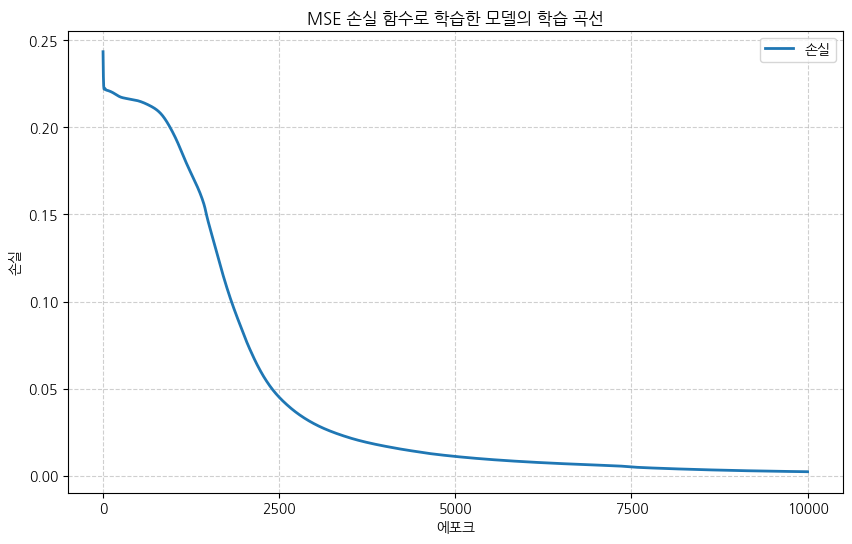

In [20]:
# 참고 - 학습 곡선 시각화 ([그림 3-11])
log_mse.plot(title='MSE 손실 함수로 학습한 모델의 학습 곡선')

- 평가 데이터로 평균제곱오차 손실 계산
    - 모델 학습에 사용하지 않은 평가 데이터로 손실을 계산해 학습 결과를 평가

In [ ]:
########################################################################################
# 코드 3-19 - 평가 데이터로 평균제곱오차 손실 계산
########################################################################################

model.eval()
with torch.no_grad():
    Y_pred_test = model(X_test)
    test_loss = criterion(Y_pred_test, Y_test_onehot)
    print(f'평가 데이터 손실: {test_loss.item():.4f}') 

평가 데이터 손실: 0.0367


- 모델의 예측 결과
    - 모델 출력 텐서의 세 요소: 각 클래스에 대한 점수의 성격을 가짐

In [22]:
########################################################################################
# 코드 3-20 - 모델 예측 결과의 형태
########################################################################################
model.eval()                                        # 평가 모드
test_sample = X_test[0]                             # 첫 번째 테스트 샘플
with torch.no_grad():
    prediction = model(test_sample)                 # (3,)
    print(f'예측 결과: {prediction.tolist()}')

예측 결과: [0.9998531341552734, 0.003959706053137779, 8.865771633281838e-06]


- 점수 형태의 예측 결과에서 예측 클래스 찾기
    - `argmax()`: 최댓값의 위치만 반환        
        - 형태와 무관하게 일렬로 나열했을 때의 순서를 반환
        - 최댓값이 둘 이상이면 둘 중 첫 번째 위치를 반환

In [23]:
########################################################################################
# 코드 3-21 - 최댓값의 위치를 반환하는 argmax() 메서드
########################################################################################

tensor_1d = torch.tensor([10, 20, 30])
tensor_3d = torch.tensor([[[10, 20], [30, 7], [20, 66]],
                          [[35, 6], [66, 25], [4, 15]]])
print(f'tensor_1d 의 최댓값의 위치: {tensor_1d.argmax()}')        # 최댓값 30의 위치 인덱스
# torch.argmax(tensor) 함수 형태로 호출해도 됨
print(f'tensor_3d 의 최댓값의 위치: {torch.argmax(tensor_3d)}')   # 최댓값 66의 첫 번째 위치 인덱스

tensor_1d 의 최댓값의 위치: 2
tensor_3d 의 최댓값의 위치: 5


- 여러 샘플의 분류 결과를 한 번에 구하는 방법
    - `dim=-1` 로 `argmax()`를 호출: 마지막 차원에서 최댓값의 위치를 집계해 여러 샘플의 분류 결과를 한 번에 반환

In [24]:
########################################################################################
# 코드 3-22 - 여러 샘플의 분류 결과를 한 번에 구하기
########################################################################################

model.eval()
test_samples = X_test[:5]
with torch.no_grad():
    predictions = model(test_samples)
    classes = predictions.argmax(dim=-1)
    print(f'분류 결과: {classes}')          # 다섯 샘플의 예측 클래스 텐서 출력

분류 결과: tensor([0, 0, 0, 0, 1])


- 평가 데이터의 분류 정확도 계산
    - 분류 결과를 원래의 정답 레이블(`Y_test`)과 비교해 정확도를 계산

In [25]:
########################################################################################
# 코드 3-23 - 평가 데이터의 분류 정확도 계산
########################################################################################

# 분류 정확도(백분율)를 계산해 반환하는 함수
def get_accuracy(model, X, Y):
    model.eval()
    with torch.no_grad():
        Y_pred = model(X)                       # 결과 예측 - (N, 3) 형태의 텐서
        classes = Y_pred.argmax(dim=-1)         # 분류 결과로 변환
        correct_count = (classes == Y).sum()
        accuracy = correct_count.item() / len(X) * 100.
        return accuracy

accuracy = get_accuracy(model, X_test, Y_test)
print(f'모델 분류 정확도: {accuracy:.2f}%')

모델 분류 정확도: 92.78%


## 교차 엔트로피 손실 함수
- 클래스별 점수를 클래스별 확률 분포로 변환하기
    - `F.softmax()` 함수 또는 `nn.Softmax` 계층으로 로짓을 0~1 사이의 확률 분포로 변환

In [26]:
########################################################################################
# 코드 3-24 - 로짓을 확률 분포로 변환
########################################################################################

# F.softmax()로 로짓을 확률 분포로 변환
logit = torch.tensor([0.35, 0.05, 0.1])     # (3,): 샘플 하나의 출력으로 가정
prob = F.softmax(logit, dim=-1)             # dim=-1: 마지막 차원을 기준으로 변환
print(f'logit 의 확률 분포: {prob}, 합계: {prob.sum()}')

# 여러 샘플을 한 번에 확률 분포로 변환할 수 있음 (F.softmax()도 가능)
# nn.Softmax 계층 객체를 사용해 로짓을 확률 분포로 변환
logits = torch.rand((2, 3))                 # (2, 3): 두 샘플의 출력으로 가정
softmax_layer = nn.Softmax(dim=-1)          # 마지막 차원을 기준으로 변환
probs = softmax_layer(logits)
print(f'logits 의 샘플별 확률값의 합계: {probs.sum(dim=-1)}')

logit 의 확률 분포: tensor([0.3969, 0.2940, 0.3091]), 합계: 1.0
logits 의 샘플별 확률값의 합계: tensor([1.0000, 1.0000])


- 참고 - 교차 엔트로피 계산에 사용하는 `-log(p)` 곡선 ([그림 3-12])
    - 정답 클래스에 모델이 부여한 확률 `p`가 1에 가까우면 손실 `-log(p)`는 0 에 가깝고, 
    - `p`가 0에 가까우면 손실이 가파르게 커짐
    - 교차 엔트로피는 '정답 클래스의 확률'에 집중해 모델을 학습하게 됨

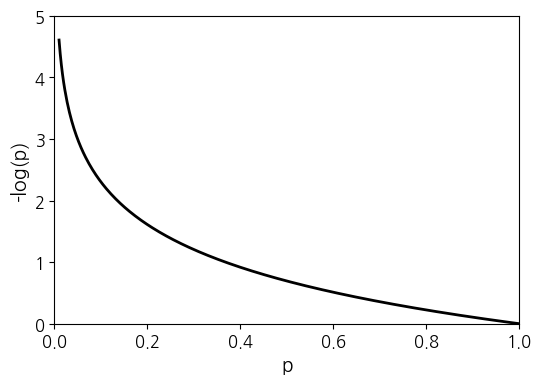

In [27]:
# 참고 - -log(p) 곡선 시각화([그림 3-12])

import matplotlib.pyplot as plt

p = np.linspace(0.01, 1.0, 400)     # log(0)은 정의되지 않으므로 0.01 부터 시작
neg_log_p = -np.log(p)              # 자연로그 기준 -log(p)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p, neg_log_p, color='black', linewidth=2)
ax.set_xlabel('p', fontsize=14)
ax.set_ylabel('-log(p)', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
ax.tick_params(labelsize=12)
plt.show()

- 시드값 재설정

In [28]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

- 교차 엔트로피 손실 함수
    - `nn.CrossEntropyLoss` 손실 함수 클래스 사용
    - 활성화 계층이 손실 함수에 포함되어 있으므로 출력층 활성화 계층 제거
    - 정답은 원-핫 벡터가 아닌 정수형 인덱스(`Y_train`, 클래스별 고유 번호)로 전달

In [29]:
########################################################################################
# 코드 3-25 - 교차 엔트로피 손실 함수를 사용해 모델 학습하기
########################################################################################

# 교차 엔트로피 손실 함수를 적용하는 모델 객체
# 손실 함수에 활성화 함수가 포함되어 있으므로 출력층에 활성화 함수를 사용하지 않음
layers_dict = OrderedDict([
    ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
    ('activation_1', nn.Sigmoid()),
    ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
    ('activation_2', nn.Sigmoid()),
    ('output', nn.Linear(HIDDEN_DIM, 3)),
])

model_celoss = nn.Sequential(layers_dict)       # 모델 객체 생성
criterion = nn.CrossEntropyLoss()               # 교차 엔트로피 손실 함수
# 손실 함수는 재사용 가능하지만, 옵티마이저는 모델을 학습할 때마다 별도로 만들어야 함
optimizer = optim.Adam(model_celoss.parameters(), lr=LR)
# 모델 학습
log_celoss = train(model_celoss, X_train, Y_train, criterion, optimizer, EPOCHS)



     에포크         손실     시간
    1/10000       1.1392     0:00


 1000/10000       0.9452     0:01
 2000/10000       0.2709     0:02
 3000/10000       0.1017     0:03
 4000/10000       0.0571     0:04
 5000/10000       0.0376     0:05
 6000/10000       0.0265     0:06
 7000/10000       0.0192     0:07
 8000/10000       0.0145     0:08
 9000/10000       0.0109     0:09
10000/10000       0.0085     0:10


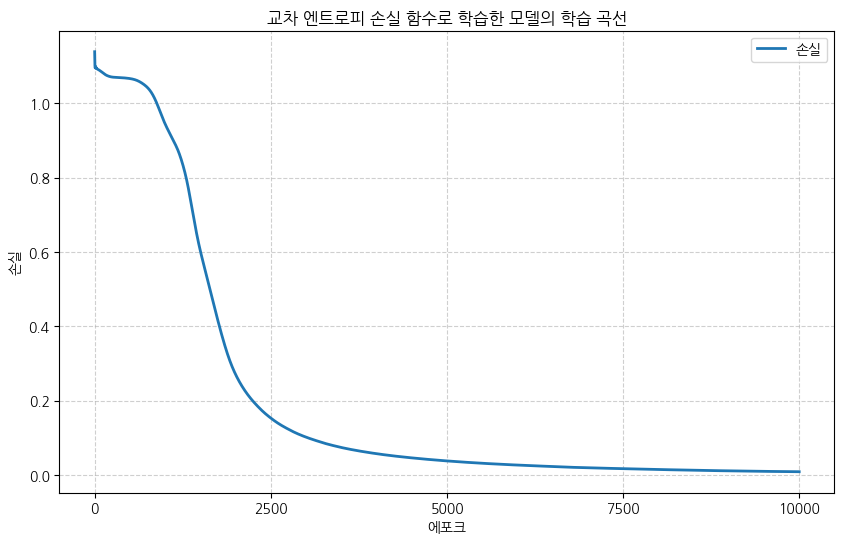

In [30]:
# 참고 - 교차 엔트로피 손실 함수로 학습한 모델의 학습 곡선

log_celoss.plot(title='교차 엔트로피 손실 함수로 학습한 모델의 학습 곡선')

- 교차 엔트로피 손실을 사용해 학습한 모델의 예측 결과
    - 마지막 활성화 계층이 없음: 소프트맥스를 통과하지 않은 로짓을 출력

In [31]:
########################################################################################
# 코드 3-26 - 교차 엔트로피 손실을 사용해 학습한 모델의 예측 결과
########################################################################################

test_sample = X_test[0]
model_celoss.eval()
with torch.no_grad():
    prediction = model_celoss(test_sample)
    print(f'예측 결과: {prediction.tolist()}')

예측 결과: [10.552910804748535, -1.4799624681472778, -5.301465034484863]


In [32]:
########################################################################################
# 코드 3-27 - 교차 엔트로피 손실을 사용해 학습한 모델의 정확도
########################################################################################

accuracy = get_accuracy(model_celoss, X_test, Y_test)
print(f'모델 분류 정확도: {accuracy:.2f}%')

모델 분류 정확도: 93.06%


- 평균제곱오차 손실 함수로 학습한 모델과 교차 엔트로피 손실 함수로 학습한 모델의 학습 곡선 비교([그림 3-13])
    - 두 손실 함수는 계산 방법이 다르므로 직접 비교할 수 없음
    - 학습의 진행 형태 비교를 위해 0~1 범위로 정규화해 같은 축에 그림

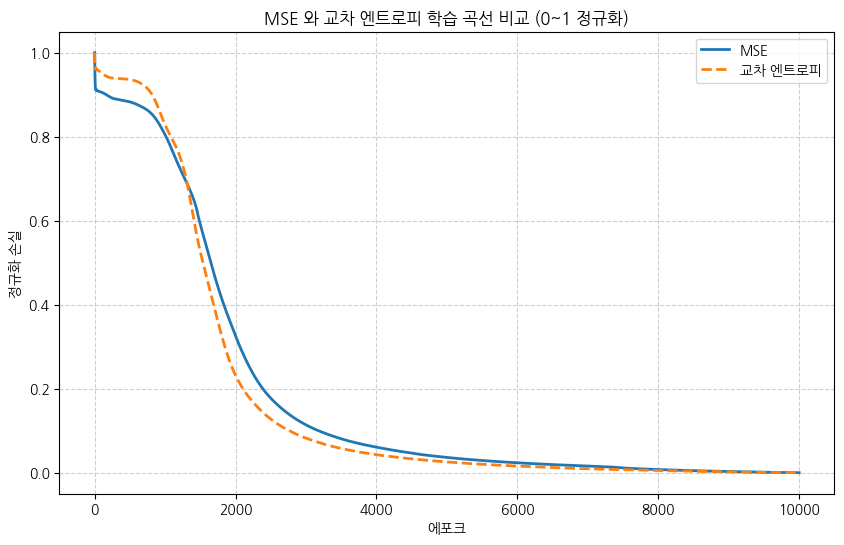

In [33]:
# 참고 - 두 학습 곡선을 0~1 범위로 정규화해 시각화([그림 3-13])

losses = log_mse.history['손실']
losses_celoss = log_celoss.history['손실']

def normalize(arr):
    a = np.asarray(arr, dtype=float)
    return ((a - a.min()) / (a.max() - a.min())).tolist()


viz.plot_histories(
    {
        'MSE': normalize(losses),
        '교차 엔트로피': normalize(losses_celoss),
    },
    title='MSE 와 교차 엔트로피 학습 곡선 비교 (0~1 정규화)',
    y_label='정규화 손실',
)

## ReLU 활성화 함수
- ReLU 활성화 함수
    - `ReLU(x) = max(0, x)`
    - 입력이 음수이면 출력은 0
    - 입력이 양수이면 그대로 출력
    - 시그모이드와 달리 양수 구간에서 기울기가 1 로 일정해 기울기 소실이 덜함

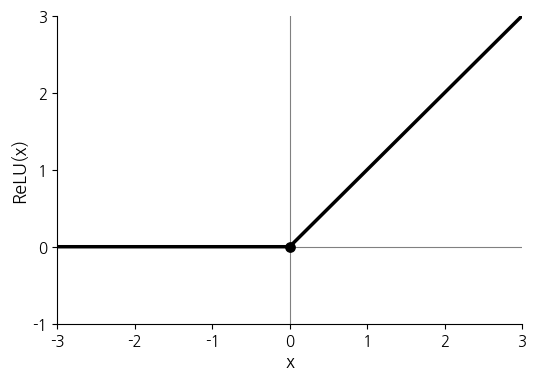

In [34]:
# 참고 - ReLU 활성화 함수 그래프([그림 3-14])

import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 400)
relu = np.maximum(0, x)             # ReLU(x) = max(0, x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.plot(x, relu, color='black', linewidth=2.5)
ax.scatter([0], [0], color='black', s=45, zorder=3)   # 꺾이는 지점 (0, 0)
ax.set_xlim(-3, 3)
ax.set_ylim(-1, 3)
ax.set_xticks(range(-3, 4))
ax.set_yticks(range(-1, 4))
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('ReLU(x)', fontsize=13)
ax.tick_params(labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

- 시드값 재설정

In [35]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

- ReLU 활성화 함수를 사용한 모델
    - 은닉층 사이의 `nn.Sigmoid()`를 `nn.ReLU()`로 교체
    - 학습에 교차 엔트로피 손실 함수를 사용하므로, 출력층 활성화 함수는 배치하지 않음
    - 학습 방법은 동일

In [36]:
########################################################################################
# 코드 3-28 - ReLU 활성화 함수를 적용해 만든 모델
########################################################################################

# 은닉층의 Sigmoid 활성화 함수를 ReLU 활성화 함수로 교체한 다층 퍼셉트론 모델
layers_dict = OrderedDict([
    ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
    ('activation_1', nn.ReLU()),
    ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
    ('activation_2', nn.ReLU()),
    ('output', nn.Linear(HIDDEN_DIM, 3)),
])

model_relu = nn.Sequential(layers_dict)         # 모델 객체 생성
optimizer = optim.Adam(model_relu.parameters(), lr=LR)
# 교차 엔트로피 손실 함수(nn.CrossEntropyLoss)를 재사용해 모델 학습
log_relu = train(model_relu, X_train, Y_train, criterion, optimizer, EPOCHS)


     에포크         손실     시간
    1/10000       1.0980     0:00
 1000/10000       0.0667     0:01
 2000/10000       0.0322     0:02
 3000/10000       0.0213     0:03
 4000/10000       0.0163     0:04
 5000/10000       0.0130     0:05
 6000/10000       0.0099     0:06
 7000/10000       0.0072     0:07
 8000/10000       0.0054     0:07
 9000/10000       0.0041     0:08
10000/10000       0.0034     0:09


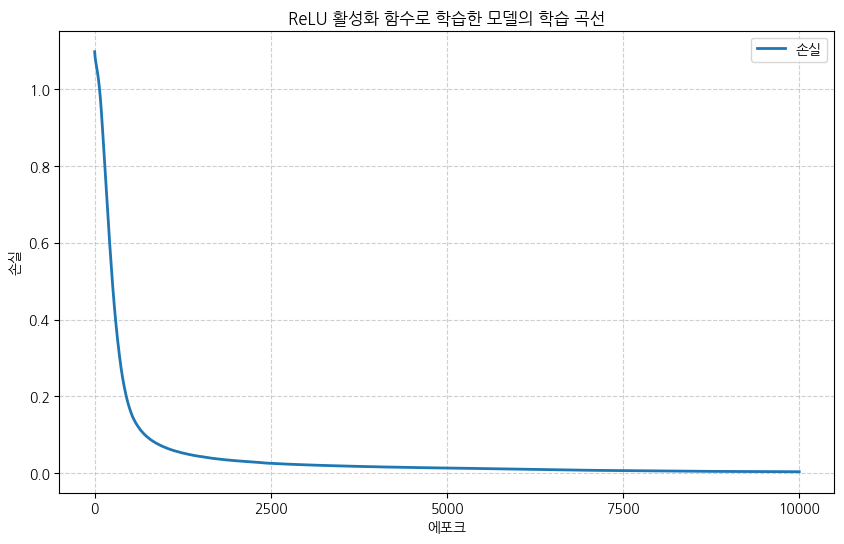

ReLU 모델 분류 정확도: 92.78%


In [37]:
# 참고 - ReLU 활성화 함수를 적용한 모델의 학습 곡선과 분류 정확도

log_relu.plot(title='ReLU 활성화 함수로 학습한 모델의 학습 곡선')

accuracy = get_accuracy(model_relu, X_test, Y_test)
print(f'ReLU 모델 분류 정확도: {accuracy:.2f}%')

- 세 모델의 학습 곡선 비교([그림 3-15]): 학습 곡선을 0~1 범위로 정규화해 겹쳐서 시각화
    - 평균제곱오차 손실 함수와 시그모이드 활성화 함수 사용(MSE + 시그모이드)
    - 교차 엔트로피 손실 함수와 시그모이드 활성화 함수 사용(교차 엔트로피 + 시그모이드)
    - 교차 엔트로피 손실 함수와 ReLU 활성화 함수 사용(교차 엔트로피 + ReLU)


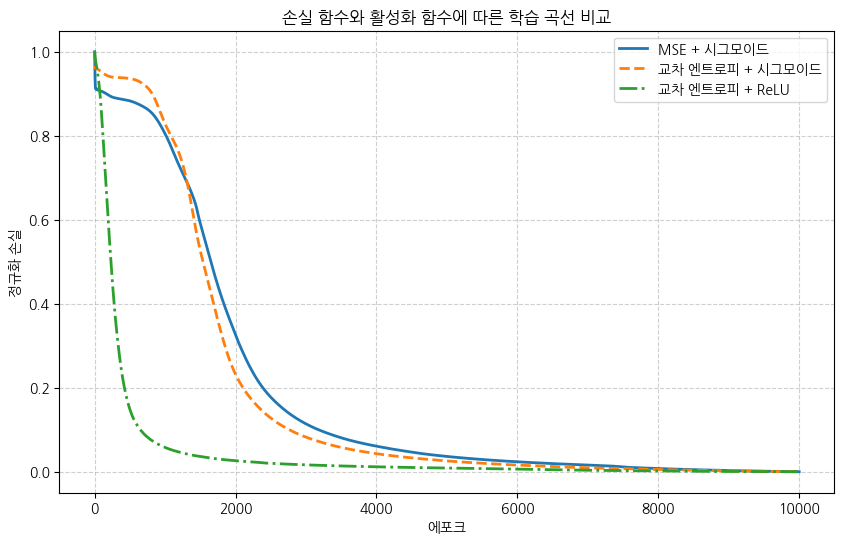

In [38]:
# 세 모델 학습 곡선 비교(0-1 범위로 정규화해 비교)([그림 3-15])
losses_relu = log_relu.history['손실']

viz.plot_histories(
    {
        'MSE + 시그모이드': normalize(losses),
        '교차 엔트로피 + 시그모이드': normalize(losses_celoss),
        '교차 엔트로피 + ReLU': normalize(losses_relu),
    },
    title='손실 함수와 활성화 함수에 따른 학습 곡선 비교',
    y_label='정규화 손실'
)